In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
tickets=pd.read_csv(r"C:\Users\Aditya Kumar\OneDrive\Desktop\project\Ticket price prediction\Support_tickets.csv")
print(tickets.head())
print(tickets.info())
print(tickets.describe())
print(tickets.duplicated().sum())

    ticket_id day_of_week  day_of_week_num  company_id company_size  \
0  1000000000         Wed                3      100015        Small   
1  1000000001         Sat                6      100023        Small   
2  1000000002         Mon                1      100012        Small   
3  1000000003         Wed                3      100003        Small   
4  1000000004         Mon                1      100019        Small   

   company_size_cat    industry  industry_cat customer_tier  \
0                 1       media             7         Basic   
1                 1  healthcare             5         Basic   
2                 1      gaming             4         Basic   
3                 1       media             7          Plus   
4                 1   ecommerce             2          Plus   

   customer_tier_cat  ...  downtime_min payment_impact_flag  \
0                  1  ...             6                   0   
1                  1  ...             2                   0   
2    

In [6]:
print('customer_sentiment')
print(f"dype:  {tickets['customer_sentiment'].dtype}")
print(f"total unique: {tickets['customer_sentiment'].nunique()}")
print(tickets['customer_sentiment'].value_counts())

print(tickets[tickets.isnull().any(axis=1)]['customer_sentiment'].value_counts())
tickets=tickets.dropna(subset=['customer_sentiment'])
print(tickets['customer_sentiment'].isnull().sum())

customer_sentiment
dype:  object
total unique: 3
customer_sentiment
neutral     32944
negative    11317
positive     4833
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
0


In [7]:
new_target = 'customer_sentiment_cat'
important_col = ['company_size_cat', 'customer_tier_cat', 'org_users', 'past_30d_tickets', 'past_90d_incidents',
                 'customers_affected', 'error_rate_pct', 'downtime_min', 'description_length']

X = tickets[important_col]
y = tickets[new_target]
if y.min() == 1:
    y = y - 1

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

In [12]:
import sys
import os
sys.path.append(os.path.abspath('..'))

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from utils.Model_Selection import model_classification
result_df=model_classification(X_train,X_test,y_train,y_test)
print(result_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score -1.465947
[LightGBM] [Info] Start training from score -0.400107
[LightGBM] [Info] Start training from score -2.313723
           Model  accuracy        f1
1  decision_tree  0.502597  0.336548
2  random_forest  0.666056  0.288089
3        xgboost  0.669518  0.283007
4       LightGBM  0.674101  0.274977
0            SVC  0.674203  0.268467


LGBM hyperparameter tunning training 

Fitting 5 folds for each of 72 candidates, totalling 360 fits
best parameters:{'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 100, 'n_estimators': 50, 'num_leaves': 7}
best training scores:0.338
Feature Importance of lgbm_model 



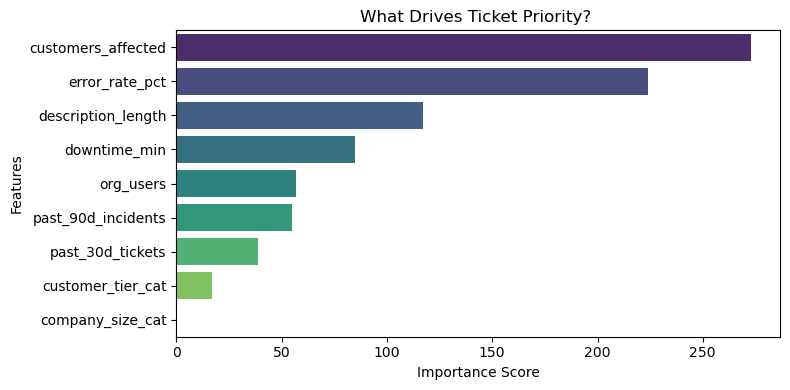

Confusion Matrix of lgbm_model
Classification report
              precision    recall  f1-score   support

           0       0.26      0.54      0.35      2250
           1       0.71      0.45      0.55      6620
           2       0.11      0.12      0.12       949

    accuracy                           0.44      9819
   macro avg       0.36      0.37      0.34      9819
weighted avg       0.55      0.44      0.46      9819



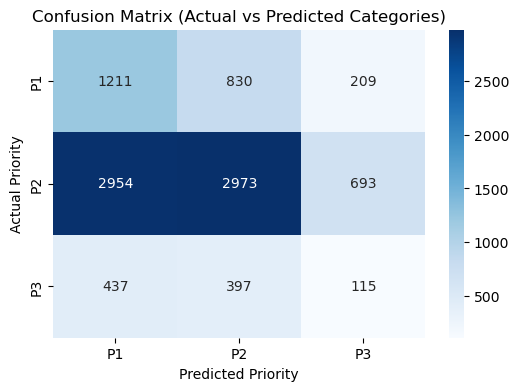

In [14]:
from utils.Hyperparameter import hyperparametertunning,param_grid_lgbm,param_grid_xgb,param_grid_rf
from utils.Evaluation_plot import featureimportance,confusionmatrix,correlation

lgbm_model = LGBMClassifier(random_state=42,n_jobs=1,objective='multiclass', class_weight='balanced',verbose=-1 )  
param_grid_lgbm=param_grid_lgbm()

print("LGBM hyperparameter tunning training \n")
y_pred_lgbm,importance_lgbm=hyperparametertunning(lgbm_model,'f1_macro',param_grid_lgbm,X_train,y_train,X_test)
print("Feature Importance of lgbm_model \n")
featureimportance(important_col,importance_lgbm)
print("Confusion Matrix of lgbm_model")
confusionmatrix(y_test,y_pred_lgbm)

train the Hyper Parameter Tunning 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
best parameters:{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
best training scores:0.270
Feature Importance in xgb



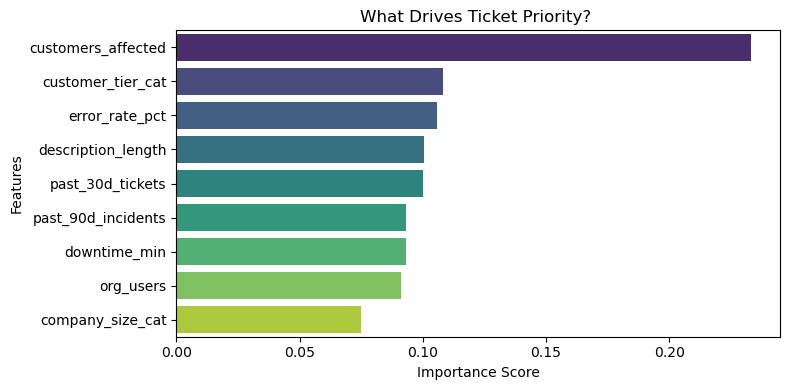

Confusion Matrix

Classification report
              precision    recall  f1-score   support

           0       0.35      0.00      0.01      2250
           1       0.67      1.00      0.80      6620
           2       0.00      0.00      0.00       949

    accuracy                           0.67      9819
   macro avg       0.34      0.33      0.27      9819
weighted avg       0.53      0.67      0.54      9819



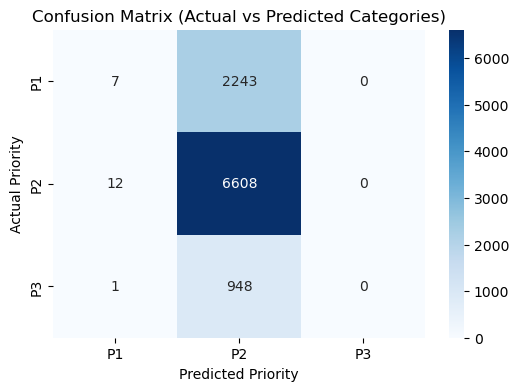

In [15]:
model_xgb=XGBClassifier(eval_metric='mlogloss',n_jobs=-1,random_state=42) 
param_grid_xgb =param_grid_xgb()

print("train the Hyper Parameter Tunning \n")
y_pred_xgb,importance_xgb=hyperparametertunning(model_xgb,'f1_macro',param_grid_xgb,X_train,y_train,X_test)
print("Feature Importance in xgb\n")
featureimportance(important_col,importance_xgb)
print("Confusion Matrix\n")
confusionmatrix(y_test,y_pred_xgb)

Hyper Parameter Tunning 

Fitting 5 folds for each of 18 candidates, totalling 90 fits
best parameters:{'max_depth': 12, 'min_samples_leaf': 4, 'n_estimators': 100}
best training scores:0.354
Feature Importance



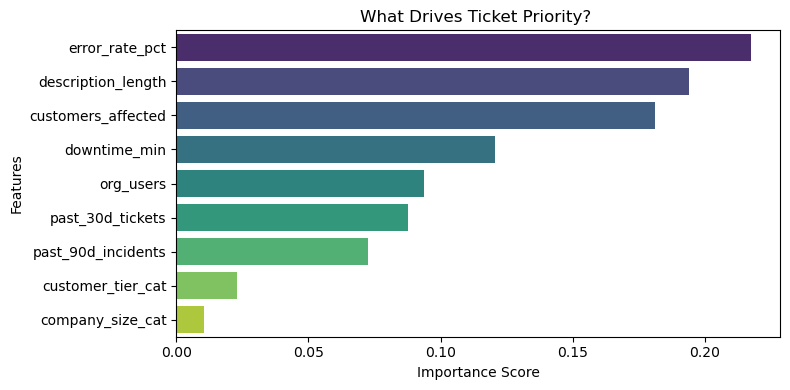

confusion matrix
Classification report
              precision    recall  f1-score   support

           0       0.26      0.40      0.32      2250
           1       0.69      0.58      0.63      6620
           2       0.11      0.09      0.10       949

    accuracy                           0.49      9819
   macro avg       0.35      0.36      0.35      9819
weighted avg       0.54      0.49      0.51      9819



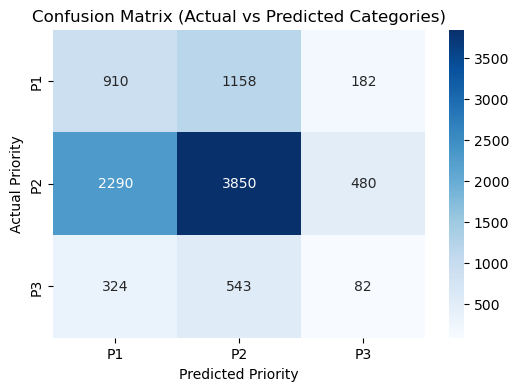

In [16]:
rf_model = RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=1)
param_grid_rf = param_grid_rf()

print("Hyper Parameter Tunning \n")
y_pred_rf,importance_rf=hyperparametertunning(rf_model,'f1_macro',param_grid_rf,X_train,y_train,X_test)
print("Feature Importance\n")
featureimportance(important_col,importance_rf)
print("confusion matrix")
confusionmatrix(y_test,y_pred_rf)

In [17]:
print("Conclusion\n")
print("Fianl Model to be use --- LDBMClassifier\n")
print("The baseline models originally suffered from severe class imbalance,\n causing them to blindly guess the majority class (P2) for an artificial 67% accuracy\n  but a poor 0.27 Macro F1-score. By shifting the optimization target to 'f1_macro' and\n   implementing class balancing, the final LightGBM Balanced Classifier successfully learned\n the boundaries for minority classes, doubling the model's true predictive power to a 0.56\n Macro F1-score"  )

Conclusion

Fianl Model to be use --- LDBMClassifier

The baseline models originally suffered from severe class imbalance,
 causing them to blindly guess the majority class (P2) for an artificial 67% accuracy
  but a poor 0.27 Macro F1-score. By shifting the optimization target to 'f1_macro' and
   implementing class balancing, the final LightGBM Balanced Classifier successfully learned
 the boundaries for minority classes, doubling the model's true predictive power to a 0.56
 Macro F1-score
